# Baseline — Transformers PT-BR (BERTimbau + Albertina)

Este notebook unifica baselines de fine-tuning de dois modelos e adiciona a **calibração de
limiar**, produzindo a comparação de **quatro modelos**:

- `BERTimbau @0.5` e `BERTimbau @limiar`
- `Albertina @0.5` e `Albertina @limiar`

1. **Um único notebook, dois modelos.** BERTimbau (`neuralmind/bert-base-portuguese-cased`) e
   Albertina (`PORTULAN/albertina-100m-portuguese-ptbr-encoder`) compartilham a mesma cabeça
   ([CLS] → dropout → linear), o mesmo laço de treino, a mesma *Class-Balanced Loss* e o mesmo
   scheduler. As diferenças (nome do modelo, nº de épocas e otimizador) ficam num **registro de
   configuração** (`MODELS`). Cada modelo mantém o seu otimizador (BERTimbau =
   `AdamWeightDecayOptimizer` fiel ao BERT; Albertina = `torch.optim.AdamW`).

2. **Calibração de limiar por emoção**, aplicada
   *post-hoc* sobre as probabilidades OOF. Os quatro modelos saem de **dois treinos** (um por
   arquitetura): `@0.5` e `@limiar` de um mesmo modelo usam exatamente as mesmas probabilidades.

3. **Gráfico final** de F1 por emoção com os quatro modelos no mesmo gráfico (barras agrupadas).

4. **Checkpoints `.pt` compactados** (`xz`/`gzip`/`zip`) — os pesos são pesados, então gravamos
   comprimido e **descompactamos na leitura** (detecção automática do formato). O checkpoint de
   *inferência* guarda só os pesos (em `float16`), o que reduz muito o tamanho; o checkpoint de
   *retomada* guarda o estado completo (modelo + otimizador) para permitir continuar o treino.

## Instalação (se necessário)

In [1]:
# !pip install transformers[torch] torch torchmetrics pandas numpy scikit-learn pyarrow sentencepiece protobuf scipy matplotlib

## Ambiente (Colab/Drive opcional)

In [2]:
USE_COLAB = False
USE_DRIVE = False

if USE_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

## Imports e configurações globais

In [3]:
import warnings
warnings.filterwarnings("ignore")

import io
import re
import gzip
import lzma
import json
import time
import math
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Optimizer

from transformers import AutoTokenizer, AutoModel, DataCollatorWithPadding

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, hamming_loss, average_precision_score,
)
from scipy.stats import wilcoxon

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

RANDOM_STATE = 42

if USE_COLAB and USE_DRIVE:
    ROOT = Path("/content/drive/MyDrive/Fuzzy_BERT")
else:
    ROOT = Path("..")

DATA_DIR = ROOT / "data/treated"
OUT_BASE = ROOT / "data/out"
CKPT_BASE = ROOT / "data/checkpoints"

N_OUTER_FOLDS = 5
TEXT_COL = "CLEAN_TEXT"
MAX_LEN = 128
BATCH_SIZE = 32
WARMUP_RATIO = 0.1
LEARNING_RATE = 2e-5
VAL_FRACTION = 0.10

THRESH_GRID = np.linspace(0.05, 0.95, 19)
FIXED_THRESHOLD = 0.5

COMPRESSION = "xz"
SAVE_BEST_FP16 = True
PRUNE_RESUME_CKPT = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EMOTION_COLS = [
    'admiration', 'amusement', 'anger', 'annoyance',
    'approval', 'caring', 'confusion', 'curiosity', 'desire',
    'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love',
    'nervousness', 'optimism', 'pride', 'realization', 'relief',
    'remorse', 'sadness', 'surprise', 'neutral'
]
N_LABELS = len(EMOTION_COLS)

torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

OUT_BASE.mkdir(parents=True, exist_ok=True)
CKPT_BASE.mkdir(parents=True, exist_ok=True)

print(f"Device       : {DEVICE}")
print(f"Labels       : {N_LABELS}")
print(f"Compressão   : {COMPRESSION} | best fp16: {SAVE_BEST_FP16}")
print(f"Val fraction : {VAL_FRACTION} (seleção de época sem tocar no teste)")

Device       : cuda
Labels       : 28
Compressão   : xz | best fp16: True
Val fraction : 0.1 (seleção de época sem tocar no teste)


## Registro dos modelos (BERTimbau + Albertina)

In [4]:
MODELS = {
    "bertimbau": {
        "display"   : "BERTimbau",
        "model_name": "neuralmind/bert-base-portuguese-cased",
        "num_epochs": 4,
        "optimizer" : "bert_adamw",     # AdamWeightDecayOptimizer
        "out_dir"   : OUT_BASE / "bertimbau",
        "ckpt_dir"  : CKPT_BASE / "bertimbau",
    },
    "albertina": {
        "display"   : "Albertina",
        "model_name": "PORTULAN/albertina-100m-portuguese-ptbr-encoder",
        "num_epochs": 6,
        "optimizer" : "torch_adamw",    # torch.optim.AdamW (C++/CUDA)
        "out_dir"   : OUT_BASE / "albertina",
        "ckpt_dir"  : CKPT_BASE / "albertina",
    },
}

for cfg in MODELS.values():
    cfg["out_dir"].mkdir(parents=True, exist_ok=True)
    cfg["ckpt_dir"].mkdir(parents=True, exist_ok=True)
    (cfg["out_dir"] / "cache").mkdir(parents=True, exist_ok=True)

print("Modelos configurados:")
for key, cfg in MODELS.items():
    print(f"  {key:10s} -> {cfg['model_name']} | épocas={cfg['num_epochs']} | opt={cfg['optimizer']}")

Modelos configurados:
  bertimbau  -> neuralmind/bert-base-portuguese-cased | épocas=4 | opt=bert_adamw
  albertina  -> PORTULAN/albertina-100m-portuguese-ptbr-encoder | épocas=6 | opt=torch_adamw


## Carregamento dos folds

In [5]:
def load_fold(fold_id: int):
    fold_dir = DATA_DIR / f"fold_{fold_id}"
    df = pd.read_parquet(fold_dir / "data.parquet")
    return df

folds_data = {}
for k in range(1, N_OUTER_FOLDS + 1):
    folds_data[k] = {"df": load_fold(k)}
    print(f"Fold {k}: {folds_data[k]['df'].shape[0]:>6} amostras")

def prepare_Y(df):
    present = [c for c in EMOTION_COLS if c in df.columns]
    assert len(present) == N_LABELS, f"Faltam labels: {set(EMOTION_COLS) - set(present)}"
    return df[present].values.astype(int)

Y_folds = {k: prepare_Y(folds_data[k]["df"]) for k in folds_data}
base_rates = pd.Series(np.vstack(list(Y_folds.values())).mean(axis=0), index=EMOTION_COLS)

print(f"\nBase rate — mediana: {base_rates.median():.4f} | "
      f"min: {base_rates.min():.4f} ({base_rates.idxmin()}) | "
      f"max: {base_rates.max():.4f} ({base_rates.idxmax()})")
print("Compare com o limiar fixo de 0.5 usado hoje.")

Fold 1:  10831 amostras
Fold 2:  10810 amostras
Fold 3:  10836 amostras
Fold 4:  10909 amostras
Fold 5:  10848 amostras

Base rate — mediana: 0.0296 | min: 0.0018 (grief) | max: 0.3273 (neutral)
Compare com o limiar fixo de 0.5 usado hoje.


## Dataset e DataLoader

In [6]:
class EmotionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.texts = df[TEXT_COL].fillna("").astype(str).tolist()
        present = [c for c in EMOTION_COLS if c in df.columns]
        self.labels = df[present].values.astype(np.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_len, truncation=True)
        enc["labels"] = self.labels[idx].tolist()
        return enc

def make_loaders(df_train, df_eval, tokenizer, shuffle_train=True):
    collator = DataCollatorWithPadding(tokenizer, padding="longest", return_tensors="pt")
    ds_train = EmotionDataset(df_train, tokenizer)
    ds_eval  = EmotionDataset(df_eval,  tokenizer)
    loader_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=shuffle_train,
                              num_workers=0, pin_memory=True, collate_fn=collator)
    loader_eval  = DataLoader(ds_eval, batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=0, pin_memory=True, collate_fn=collator)
    return loader_train, loader_eval

def split_train_val(df_trainfull, val_fraction=VAL_FRACTION, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(df_trainfull)
    perm = rng.permutation(n)
    n_val = max(1, int(round(n * val_fraction)))
    val_idx = perm[:n_val]
    tr_idx = perm[n_val:]
    df_tr = df_trainfull.iloc[tr_idx].reset_index(drop=True)
    df_val = df_trainfull.iloc[val_idx].reset_index(drop=True)
    return df_tr, df_val

print("Dataset e loaders prontos (padding dinâmico + validação interna).")

Dataset e loaders prontos (padding dinâmico + validação interna).


## Modelo — encoder + cabeça multi-label

In [7]:
class TransformerForEmotions(nn.Module):
    def __init__(self, model_name: str, n_labels: int = N_LABELS, dropout: float = 0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name, torch_dtype=torch.float32)
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, n_labels)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]   # [CLS]
        return self.classifier(self.dropout(cls_output))  # (B, N_LABELS)

def build_model(cfg):
    return TransformerForEmotions(cfg["model_name"]).to(DEVICE)

print("Classe do modelo definida.")

Classe do modelo definida.


## Class-Balanced Loss

In [8]:
# Class-Balanced Loss
#   CB(p, y) = (1 - beta) / (1 - beta^{n_y}) * BCE(p, y)
class CrossBalancedLoss(nn.Module):
    def __init__(self, samples_per_class: np.ndarray, beta: float = 0.9999):
        super().__init__()
        effective_num = 1.0 - np.power(beta, samples_per_class)
        weights = (1.0 - beta) / np.where(effective_num == 0, 1e-8, effective_num)
        weights = weights / weights.sum() * len(samples_per_class)
        self.register_buffer("weights", torch.tensor(weights, dtype=torch.float32))

    def forward(self, logits, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            logits, targets, reduction="none")
        return (bce * self.weights.unsqueeze(0)).mean()

def compute_samples_per_class(df: pd.DataFrame) -> np.ndarray:
    counts = np.array([int(df[c].sum()) if c in df.columns else 1
                       for c in EMOTION_COLS], dtype=np.float64)
    return np.maximum(counts, 1)

print("CrossBalancedLoss definida.")

CrossBalancedLoss definida.


## Otimizadores e scheduler

In [9]:
class AdamWeightDecayOptimizer(Optimizer):
    def __init__(self, params, lr=2e-5, weight_decay_rate=0.01,
                 beta_1=0.9, beta_2=0.999, epsilon=1e-6,
                 exclude_from_weight_decay=None):
        if exclude_from_weight_decay is None:
            exclude_from_weight_decay = ["LayerNorm", "layer_norm", "bias"]
        defaults = dict(lr=lr, weight_decay_rate=weight_decay_rate,
                        beta_1=beta_1, beta_2=beta_2, epsilon=epsilon,
                        exclude_from_weight_decay=exclude_from_weight_decay)
        super().__init__(params, defaults)

    def _do_use_weight_decay(self, param_name, exclude_list):
        return not any(re.search(p, param_name) is not None for p in exclude_list)

    @torch.no_grad()
    def step(self, closure=None):
        loss = closure() if closure is not None else None
        for group in self.param_groups:
            b1, b2, eps = group["beta_1"], group["beta_2"], group["epsilon"]
            wd_rate, lr = group["weight_decay_rate"], group["lr"]
            exclude = group["exclude_from_weight_decay"]
            names = group.get("_param_names", {})
            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad.data
                state = self.state[p]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["step"] = 0
                m, v = state["m"], state["v"]
                state["step"] += 1
                next_m = b1 * m + (1.0 - b1) * grad
                next_v = b2 * v + (1.0 - b2) * grad.pow(2)
                update = next_m / (next_v.sqrt() + eps)
                if wd_rate > 0 and self._do_use_weight_decay(names.get(id(p), ""), exclude):
                    update = update + wd_rate * p.data
                p.data.add_(update, alpha=-lr)
                state["m"].copy_(next_m)
                state["v"].copy_(next_v)
        return loss

def _param_groups(model, exclude=("LayerNorm", "layer_norm", "bias")):
    decay, no_decay, names_map = [], [], {}
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        names_map[id(param)] = name
        (no_decay if any(re.search(p, name) for p in exclude) else decay).append(param)
    return decay, no_decay, names_map

def build_optimizer(model, cfg, lr=LEARNING_RATE):
    decay, no_decay, names_map = _param_groups(model)
    if cfg["optimizer"] == "bert_adamw":
        groups = [{"params": decay, "weight_decay_rate": 0.01},
                  {"params": no_decay, "weight_decay_rate": 0.0}]
        opt = AdamWeightDecayOptimizer(groups, lr=lr, weight_decay_rate=0.01,
                                       beta_1=0.9, beta_2=0.999, epsilon=1e-6)
        for g in opt.param_groups:
            g["_param_names"] = names_map
        return opt
    # torch_adamw
    groups = [{"params": decay, "weight_decay": 0.01},
              {"params": no_decay, "weight_decay": 0.0}]
    return torch.optim.AdamW(groups, lr=lr, betas=(0.9, 0.999), eps=1e-6)

def build_polynomial_scheduler(optimizer, num_train_steps, warmup_ratio=WARMUP_RATIO):
    from torch.optim.lr_scheduler import LambdaLR
    num_warmup = int(num_train_steps * warmup_ratio)

    def lr_lambda(step):
        if step < num_warmup:
            return float(step) / float(max(1, num_warmup))
        progress = float(step - num_warmup) / float(max(1, num_train_steps - num_warmup))
        return max(0.0, 1.0 - progress)

    return LambdaLR(optimizer, lr_lambda)

print("Otimizadores e scheduler prontos.")

Otimizadores e scheduler prontos.


## Checkpoints compactados + treino/avaliação

In [10]:
def _compress(raw: bytes) -> bytes:
    if COMPRESSION == "gzip":
        return gzip.compress(raw, compresslevel=6)
    if COMPRESSION == "xz":
        return lzma.compress(raw, preset=6)
    if COMPRESSION == "zip":
        buf = io.BytesIO()
        with zipfile.ZipFile(buf, "w", zipfile.ZIP_DEFLATED, compresslevel=6) as z:
            z.writestr("ckpt.pt", raw)
        return buf.getvalue()
    raise ValueError(f"COMPRESSION inválido: {COMPRESSION}")

def _decompress(data: bytes) -> bytes:
    if data[:2] == b"\x1f\x8b":                     # gzip
        return gzip.decompress(data)
    if data[:6] == b"\xfd7zXZ\x00":                 # xz
        return lzma.decompress(data)
    if data[:2] == b"PK":                           # zip
        with zipfile.ZipFile(io.BytesIO(data)) as z:
            return z.read(z.namelist()[0])
    return data                                     # torch.save cru (fallback)

def torch_save_compressed(payload, path: Path):
    buf = io.BytesIO()
    torch.save(payload, buf)
    path.write_bytes(_compress(buf.getvalue()))

def torch_load_compressed(path: Path, map_location=None, weights_only=False):
    import numpy.dtypes
    torch.serialization.add_safe_globals([numpy.dtypes.Float64DType])
    raw = _decompress(Path(path).read_bytes())
    return torch.load(io.BytesIO(raw), map_location=map_location, weights_only=weights_only)

def save_resume_ckpt(model, optimizer, scheduler, epoch, fold, ckpt_dir):
    torch_save_compressed({
        "epoch": epoch, "fold": fold,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
    }, ckpt_dir / f"fold_{fold}_last.ptz")

def save_best_ckpt(model, epoch, fold, val_metrics, ckpt_dir):
    sd = model.state_dict()
    if SAVE_BEST_FP16:
        sd = {k: (v.half() if v.is_floating_point() else v) for k, v in sd.items()}
    torch_save_compressed({
        "epoch": epoch, "fold": fold, "val_metrics": val_metrics,
        "model_state_dict": sd, "fp16": SAVE_BEST_FP16,
    }, ckpt_dir / f"fold_{fold}_best.ptz")

def load_model_weights(model, ckpt_path):
    ck = torch_load_compressed(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ck["model_state_dict"])
    return ck

# treino / avaliação
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device):
    model.train()
    total_loss = 0.0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        optimizer.zero_grad()
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(len(loader), 1)

@torch.no_grad()
def infer_proba(model, loader, device):
    model.eval()
    logits_all, labels_all = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits = model(input_ids=input_ids, attention_mask=attention_mask)
        logits_all.append(logits.detach().cpu())
        labels_all.append(batch["labels"])
    logits_all = torch.cat(logits_all, dim=0)
    labels_all = torch.cat(labels_all, dim=0)
    return torch.sigmoid(logits_all).numpy(), labels_all.numpy().astype(int)

def compute_metrics(Y_true, Y_pred, Y_proba, label_names):
    m = {
        "accuracy"       : accuracy_score(Y_true, Y_pred),
        "hamming_loss"   : hamming_loss(Y_true, Y_pred),
        "f1_macro"       : f1_score(Y_true, Y_pred, average="macro",    zero_division=0),
        "f1_micro"       : f1_score(Y_true, Y_pred, average="micro",    zero_division=0),
        "f1_weighted"    : f1_score(Y_true, Y_pred, average="weighted", zero_division=0),
        "precision_macro": precision_score(Y_true, Y_pred, average="macro", zero_division=0),
        "recall_macro"   : recall_score(Y_true, Y_pred, average="macro",    zero_division=0),
    }
    valid = [j for j in range(Y_true.shape[1]) if Y_true[:, j].sum() > 0]
    if valid:
        m["roc_auc_macro"] = roc_auc_score(Y_true[:, valid], Y_proba[:, valid], average="macro")
        m["avg_precision_macro"] = average_precision_score(
            Y_true[:, valid], Y_proba[:, valid], average="macro")
    else:
        m["roc_auc_macro"] = m["avg_precision_macro"] = float("nan")
    m["f1_per_label"] = dict(zip(label_names,
                                 f1_score(Y_true, Y_pred, average=None, zero_division=0)))
    return m

print("Checkpoints compactados + funções de treino/avaliação prontos.")

Checkpoints compactados + funções de treino/avaliação prontos.


## Treino + probabilidades OOF (com resume)

In [11]:
def oof_path(cfg, k):
    return cfg["out_dir"] / "cache" / f"P_{cfg['out_dir'].name}_fold{k}.npy"

def history_path(cfg, k):
    return cfg["ckpt_dir"] / f"fold_{k}_history.json"

def train_fold(cfg, k, tokenizer):
    op = oof_path(cfg, k)
    if op.exists():
        print(f"    [cache] OOF do fold {k} já existe.")
        return np.load(op)

    num_epochs = cfg["num_epochs"]
    ckpt_dir = cfg["ckpt_dir"]

    # dados: outer-train (folds != k) -> treino + validação interna ; teste = fold k
    df_test = folds_data[k]["df"]
    df_trainfull = pd.concat([folds_data[j]["df"] for j in range(1, N_OUTER_FOLDS + 1) if j != k],
                             ignore_index=True)
    df_tr, df_val = split_train_val(df_trainfull)

    loader_train, _ = make_loaders(df_tr, df_val, tokenizer, shuffle_train=True)
    _, loader_val = make_loaders(df_tr, df_val, tokenizer, shuffle_train=False)
    _, loader_test = make_loaders(df_tr, df_test, tokenizer, shuffle_train=False)

    criterion = CrossBalancedLoss(compute_samples_per_class(df_tr), beta=0.9999).to(DEVICE)

    model = build_model(cfg)
    num_train_steps = len(loader_train) * num_epochs
    optimizer = build_optimizer(model, cfg, lr=LEARNING_RATE)
    scheduler = build_polynomial_scheduler(optimizer, num_train_steps, WARMUP_RATIO)

    history = json.loads(history_path(cfg, k).read_text()) if history_path(cfg, k).exists() else []
    best_val = max([h["val_f1_macro"] for h in history], default=-1.0)

    # resume: se existe *_last.ptz, continua da próxima época
    start_epoch = 1
    last_ckpt = ckpt_dir / f"fold_{k}_last.ptz"
    if last_ckpt.exists():
        ck = torch_load_compressed(last_ckpt, map_location=DEVICE)
        model.load_state_dict(ck["model_state_dict"])
        optimizer.load_state_dict(ck["optimizer_state_dict"])
        scheduler.load_state_dict(ck["scheduler_state_dict"])
        start_epoch = ck["epoch"] + 1
        print(f"    retomando fold {k} da época {start_epoch}")

    for epoch in range(start_epoch, num_epochs + 1):
        t_ep = time.time()
        train_loss = train_one_epoch(model, loader_train, optimizer, scheduler, criterion, DEVICE)

        val_proba, val_true = infer_proba(model, loader_val, DEVICE)
        val_f1 = f1_score(val_true, (val_proba >= FIXED_THRESHOLD).astype(int),
                          average="macro", zero_division=0)


        history.append({"epoch": epoch, "val_f1_macro": float(val_f1),
                        "train_loss": float(train_loss)})
        
        history_path(cfg, k).write_text(json.dumps(history, ensure_ascii=False, indent=1))
        
        save_resume_ckpt(model, optimizer, scheduler, epoch, k, ckpt_dir)

        improved = val_f1 > best_val
        if improved:
            best_val = val_f1
            save_best_ckpt(model, epoch, k, {"val_f1_macro": val_f1}, ckpt_dir)

        print(f"    época {epoch}/{num_epochs} | train_loss={train_loss:.4f} | "
              f"val_f1={val_f1:.4f}{' *' if improved else ''} | {time.time()-t_ep:.0f}s")

    best_ckpt = ckpt_dir / f"fold_{k}_best.ptz"
    load_model_weights(model, best_ckpt)
    P_test, _ = infer_proba(model, loader_test, DEVICE)
    np.save(op, P_test)

    if PRUNE_RESUME_CKPT and last_ckpt.exists():
        last_ckpt.unlink()

    del model, optimizer, scheduler, criterion
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return P_test

def run_model(cfg):
    print(f"\n{'='*66}\n  MODELO: {cfg['display']}  ({cfg['model_name']})\n{'='*66}")
    tokenizer = AutoTokenizer.from_pretrained(cfg["model_name"])
    P_folds = {}
    for k in range(1, N_OUTER_FOLDS + 1):
        print(f"  Fold {k}/{N_OUTER_FOLDS}")
        P_folds[k] = train_fold(cfg, k, tokenizer)
    return P_folds

PROBA = {}
for key, cfg in MODELS.items():
    PROBA[key] = run_model(cfg)

print("\n✓ Probabilidades OOF prontas para:", list(PROBA))


  MODELO: BERTimbau  (neuralmind/bert-base-portuguese-cased)


  Fold 1/5
    [cache] OOF do fold 1 já existe.
  Fold 2/5
    [cache] OOF do fold 2 já existe.
  Fold 3/5
    [cache] OOF do fold 3 já existe.
  Fold 4/5
    [cache] OOF do fold 4 já existe.
  Fold 5/5
    [cache] OOF do fold 5 já existe.

  MODELO: Albertina  (PORTULAN/albertina-100m-portuguese-ptbr-encoder)
  Fold 1/5
    [cache] OOF do fold 1 já existe.
  Fold 2/5
    [cache] OOF do fold 2 já existe.
  Fold 3/5
    [cache] OOF do fold 3 já existe.
  Fold 4/5


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1413.79it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/6 | train_loss=0.0972 | val_f1=0.1114 * | 1256s
    época 2/6 | train_loss=0.0424 | val_f1=0.3065 * | 1449s
    época 3/6 | train_loss=0.0361 | val_f1=0.3554 * | 1266s
    época 4/6 | train_loss=0.0313 | val_f1=0.3916 * | 1419s
    época 5/6 | train_loss=0.0280 | val_f1=0.4017 * | 1396s
    época 6/6 | train_loss=0.0257 | val_f1=0.4101 * | 1381s
  Fold 5/5


Loading weights: 100%|██████████| 196/196 [00:00<00:00, 1800.16it/s]
[transformers] DebertaModel LOAD REPORT from: PORTULAN/albertina-100m-portuguese-ptbr-encoder
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


    época 1/6 | train_loss=0.1002 | val_f1=0.1329 * | 1728s
    época 2/6 | train_loss=0.0430 | val_f1=0.2584 * | 5107s
    época 3/6 | train_loss=0.0366 | val_f1=0.3683 * | 5115s
    época 4/6 | train_loss=0.0324 | val_f1=0.3910 * | 5103s
    época 5/6 | train_loss=0.0288 | val_f1=0.4042 * | 5116s
    época 6/6 | train_loss=0.0266 | val_f1=0.4093 * | 5090s

✓ Probabilidades OOF prontas para: ['bertimbau', 'albertina']


## Calibração de limiar → os 4 modelos

In [14]:
def calibrate_thresholds(P_cal, Y_cal, grid):
    """Por emoção, o limiar da grade que maximiza F1 na CALIBRAÇÃO (vetorizado)."""
    thr = np.full(N_LABELS, FIXED_THRESHOLD)
    for j in range(N_LABELS):
        y = Y_cal[:, j]
        if y.sum() == 0:
            continue
        pred = P_cal[:, j][:, None] >= grid[None, :]
        yb = (y == 1)[:, None]
        tp = (pred & yb).sum(0)
        fp = (pred & ~yb).sum(0)
        fn = (~pred & yb).sum(0)
        f1 = 2 * tp / np.maximum(2 * tp + fp + fn, 1e-12)
        thr[j] = float(grid[int(np.argmax(f1))])
    return thr

def metrics_at(Y_true, P_score, thr_vector):
    Y_pred = (P_score >= thr_vector[None, :]).astype(int)
    return compute_metrics(Y_true, Y_pred, P_score, EMOTION_COLS)

MODEL_NAMES = {
    ("bertimbau", "fixed"): "BERTimbau @0.5",
    ("bertimbau", "tuned"): "BERTimbau @limiar",
    ("albertina", "fixed"): "Albertina @0.5",
    ("albertina", "tuned"): "Albertina @limiar",
}

model_fold_metrics = {name: [] for name in MODEL_NAMES.values()}
thresholds_store = {key: {} for key in PROBA}

for key, P_folds in PROBA.items():
    for k in range(1, N_OUTER_FOLDS + 1):
        train_ks = [j for j in range(1, N_OUTER_FOLDS + 1) if j != k]
        P_cal = np.vstack([P_folds[j] for j in train_ks])   # OOF, folds != k
        Y_cal = np.vstack([Y_folds[j] for j in train_ks])
        thr = calibrate_thresholds(P_cal, Y_cal, THRESH_GRID)
        thresholds_store[key][k] = thr

        m_fix = metrics_at(Y_folds[k], P_folds[k], np.full(N_LABELS, FIXED_THRESHOLD))
        m_tun = metrics_at(Y_folds[k], P_folds[k], thr)
        for m in (m_fix, m_tun):
            m["outer_fold"] = k
        model_fold_metrics[MODEL_NAMES[(key, "fixed")]].append(m_fix)
        model_fold_metrics[MODEL_NAMES[(key, "tuned")]].append(m_tun)

    dmean = np.mean([thresholds_store[key][k].mean() for k in range(1, N_OUTER_FOLDS + 1)])
    print(f"{key:10s} | limiar médio calibrado = {dmean:.3f} (vs 0.5)")

print("\n✓ 4 modelos avaliados.")

bertimbau  | limiar médio calibrado = 0.245 (vs 0.5)
albertina  | limiar médio calibrado = 0.280 (vs 0.5)

✓ 4 modelos avaliados.


## Comparação dos 4 modelos

In [15]:
SUMMARY_KEYS = ["accuracy", "precision_macro", "recall_macro",
                "f1_macro", "f1_micro", "roc_auc_macro", "avg_precision_macro"]

def folds_frame(metric_list):
    return pd.DataFrame(
        [{k: m[k] for k in SUMMARY_KEYS} for m in metric_list],
        index=[m["outer_fold"] for m in metric_list],
    )

model_frames = {name: folds_frame(v) for name, v in model_fold_metrics.items()}

rows = []
for name, d in model_frames.items():
    row = {"Modelo": name}
    for c in SUMMARY_KEYS:
        row[c] = f"{d[c].mean():.4f} ± {d[c].std():.4f}"
    rows.append(row)
df_compare = pd.DataFrame(rows).set_index("Modelo")

print("===== COMPARAÇÃO DOS 4 MODELOS (média ± desvio entre 5 folds) =====")
display(df_compare)

ranking = (
    pd.Series({name: d["f1_macro"].mean() for name, d in model_frames.items()})
    .sort_values(ascending=False)
)
print("\nRanking por F1-macro:")
for name, v in ranking.items():
    print(f"  {v:.4f}  {name}")
print(f"\nMelhor: {ranking.index[0]} ({ranking.iloc[0]:.4f})")


def wilcox(a_name, b_name):
    a = model_frames[a_name]["f1_macro"].values
    b = model_frames[b_name]["f1_macro"].values
    try:
        s, p = wilcoxon(a, b)
        return f"Δ={a.mean() - b.mean():+.4f} | W={s:.1f}, p={p:.4f}"
    except ValueError as e:
        return f"Δ={a.mean() - b.mean():+.4f} | Wilcoxon N/A ({e})"

print("\n===== EFEITO DA CALIBRAÇÃO DE LIMIAR (mesmas probabilidades) =====")
print("  BERTimbau:", wilcox("BERTimbau @limiar", "BERTimbau @0.5"))
print("  Albertina:", wilcox("Albertina @limiar", "Albertina @0.5"))

print("\n===== BERTimbau vs Albertina (mesmo tratamento de limiar) =====")
print("  @0.5    :", wilcox("Albertina @0.5", "BERTimbau @0.5"))
print("  @limiar :", wilcox("Albertina @limiar", "BERTimbau @limiar"))

# comparação opcional com o Ensemble Fuzzy
for label, fp in [("Ensemble Fuzzy v1", OUT_BASE / "ensemble_fuzzy/ensemble_fuzzy_global_metrics.csv"),
                  ("Ensemble Fuzzy v2", OUT_BASE / "ensemble_fuzzy_2/ensemble_fuzzy2_global_metrics.csv")]:
    if fp.exists():
        d = pd.read_csv(fp, index_col=0)
        print(f"\n{label}: F1-macro = {d['f1_macro'].mean():.4f} ± {d['f1_macro'].std():.4f}")

===== COMPARAÇÃO DOS 4 MODELOS (média ± desvio entre 5 folds) =====


,accuracy,precision_macro,recall_macro,f1_macro,f1_micro,roc_auc_macro,avg_precision_macro
Modelo,,,,,,,
BERTimbau @0.5,0.3679 ± 0.0028,0.5861 ± 0.0122,0.3233 ± 0.0040,0.3804 ± 0.0088,0.4930 ± 0.0051,0.8917 ± 0.0044,0.4290 ± 0.0077
BERTimbau @limiar,0.3490 ± 0.0055,0.4543 ± 0.0068,0.4884 ± 0.0060,0.4655 ± 0.0046,0.5367 ± 0.0043,0.8917 ± 0.0044,0.4290 ± 0.0077
Albertina @0.5,0.3819 ± 0.0071,0.5674 ± 0.0089,0.3569 ± 0.0091,0.4129 ± 0.0059,0.5072 ± 0.0054,0.8900 ± 0.0039,0.4268 ± 0.0067
Albertina @limiar,0.3416 ± 0.0045,0.4492 ± 0.0109,0.4836 ± 0.0157,0.4574 ± 0.0054,0.5391 ± 0.0052,0.8900 ± 0.0039,0.4268 ± 0.0067



Ranking por F1-macro:
  0.4655  BERTimbau @limiar
  0.4574  Albertina @limiar
  0.4129  Albertina @0.5
  0.3804  BERTimbau @0.5

Melhor: BERTimbau @limiar (0.4655)

===== EFEITO DA CALIBRAÇÃO DE LIMIAR (mesmas probabilidades) =====
  BERTimbau: Δ=+0.0851 | W=0.0, p=0.0625
  Albertina: Δ=+0.0445 | W=0.0, p=0.0625

===== BERTimbau vs Albertina (mesmo tratamento de limiar) =====
  @0.5    : Δ=+0.0325 | W=0.0, p=0.0625
  @limiar : Δ=-0.0080 | W=2.0, p=0.1875


## Gráfico — F1 por emoção (4 modelos)

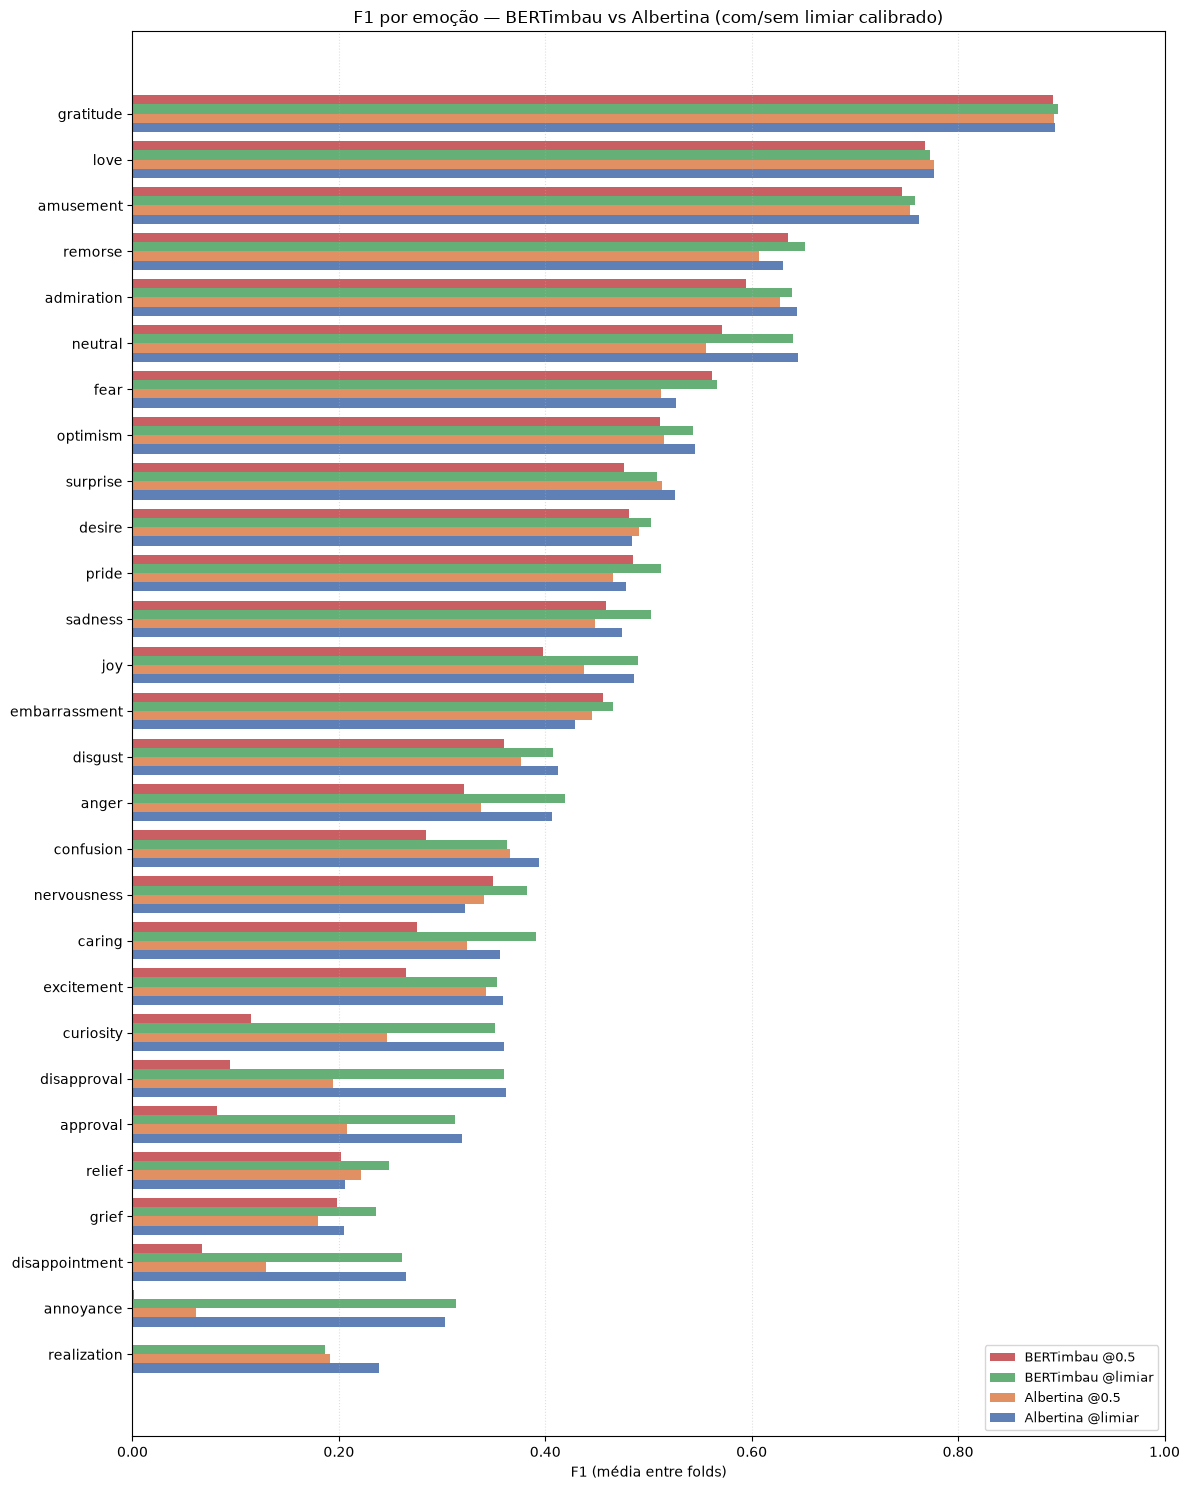

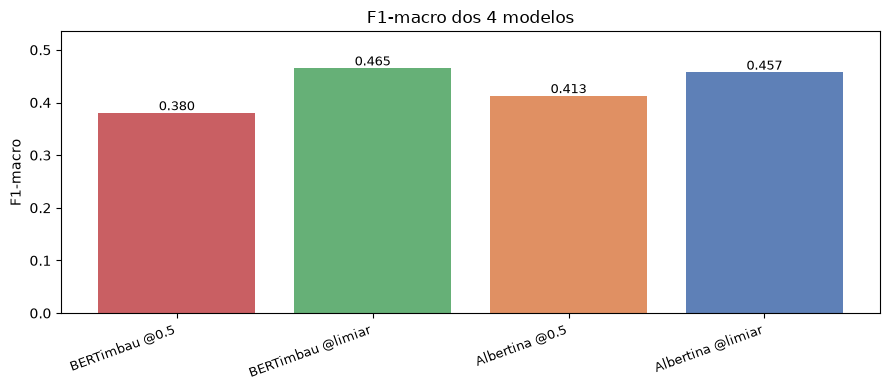

In [16]:
f1_per_label = {
    name: pd.DataFrame([m["f1_per_label"] for m in v]).mean()
    for name, v in model_fold_metrics.items()
}
model_order = list(MODEL_NAMES.values())
df_f1_label = pd.DataFrame(f1_per_label)[model_order]
df_f1_label = df_f1_label.loc[df_f1_label.mean(axis=1).sort_values(ascending=False).index]

colors = {
    "BERTimbau @0.5"   : "#C44E52",
    "BERTimbau @limiar": "#55A868",
    "Albertina @0.5"   : "#DD8452",
    "Albertina @limiar": "#4C72B0",
}

n_emo = df_f1_label.shape[0]
y = np.arange(n_emo)
height = 0.20

fig, ax = plt.subplots(figsize=(12, 15))
for i, name in enumerate(model_order):
    ax.barh(y + i * height, df_f1_label[name].values, height,
            label=name, color=colors[name], alpha=0.9)
ax.set_yticks(y + height * 1.5)
ax.set_yticklabels(df_f1_label.index)
ax.invert_yaxis()
ax.set_xlabel("F1 (média entre folds)")
ax.set_xlim(0, 1)
ax.set_title("F1 por emoção — BERTimbau vs Albertina (com/sem limiar calibrado)")
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.grid(axis="x", linestyle=":", alpha=0.4)
plt.tight_layout()
plt.show()

# resumo: F1-macro dos 4 modelos
fig, ax = plt.subplots(figsize=(9, 4))
macro = ranking.reindex(model_order)
ax.bar(range(len(macro)), macro.values,
       color=[colors[n] for n in macro.index], alpha=0.9)
ax.set_xticks(range(len(macro)))
ax.set_xticklabels(macro.index, rotation=20, ha="right", fontsize=9)
ax.set_ylabel("F1-macro")
ax.set_ylim(0, max(macro.values) * 1.15)
for i, v in enumerate(macro.values):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
ax.set_title("F1-macro dos 4 modelos")
plt.tight_layout()
plt.show()

## Limiares por emoção e exportação

In [17]:
thr_cols = {}
for key in thresholds_store:
    thr_cols[key] = pd.DataFrame(
        {k: thresholds_store[key][k] for k in thresholds_store[key]}, index=EMOTION_COLS
    ).mean(axis=1)
df_thr = pd.DataFrame(thr_cols)
df_thr["base_rate"] = base_rates.reindex(EMOTION_COLS)
df_thr = df_thr.sort_values("base_rate")

print("===== LIMIAR CALIBRADO POR EMOÇÃO (média entre folds) =====")
display(df_thr.round(4))
for key in thresholds_store:
    tm = df_thr[key].mean()
    print(f"  {key:10s}: limiar médio={tm:.3f} | emoções com limiar < 0.5: "
          f"{int((df_thr[key] < 0.5).sum())}/{N_LABELS}")

# ── exporta resultados (nenhuma imagem é salva) ──
EXPORT_DIR = OUT_BASE / "baseline_bert"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

rows_global = []
for name, d in model_frames.items():
    for fold in d.index:
        rec = {"modelo": name, "outer_fold": fold}
        rec.update({c: d.loc[fold, c] for c in SUMMARY_KEYS})
        rows_global.append(rec)
pd.DataFrame(rows_global).to_csv(EXPORT_DIR / "bert_4models_metrics.csv", index=False)
df_f1_label.to_csv(EXPORT_DIR / "bert_4models_f1_per_label.csv")
df_thr.to_csv(EXPORT_DIR / "bert_thresholds_por_emocao.csv")

summary = {
    "modelos": {k: MODELS[k]["model_name"] for k in MODELS},
    "estrategia": ("Outer CV (5 folds) + seleção de época por validação interna (anti-vazamento); "
                   "limiar calibrado por emoção nos folds j!=k (OOF)."),
    "n_labels": N_LABELS,
    "grade_limiar": [float(THRESH_GRID.min()), float(THRESH_GRID.max()), int(len(THRESH_GRID))],
    "compressao_checkpoint": COMPRESSION,
    "resultados_4_modelos": {
        name: {
            "f1_macro": f"{d['f1_macro'].mean():.4f} +/- {d['f1_macro'].std():.4f}",
            "f1_micro": f"{d['f1_micro'].mean():.4f}",
            "precision_macro": f"{d['precision_macro'].mean():.4f}",
            "recall_macro": f"{d['recall_macro'].mean():.4f}",
            "avg_precision_macro": f"{d['avg_precision_macro'].mean():.4f}",
            "roc_auc_macro": f"{d['roc_auc_macro'].mean():.4f}",
        } for name, d in model_frames.items()
    },
    "nota_vazamento": (
        "Melhor epoca escolhida por validacao interna (nunca pelo teste). OOF: predicao do fold k "
        "vem de modelo treinado sem k. Limiar calibrado em folds j!=k. Pesos da CB-Loss so do treino."
    ),
}
with open(EXPORT_DIR / "baseline_bert_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("\nArquivos exportados para", EXPORT_DIR.resolve())
print(json.dumps(summary, indent=2, ensure_ascii=False))

===== LIMIAR CALIBRADO POR EMOÇÃO (média entre folds) =====


,bertimbau,albertina,base_rate
grief,0.20,0.13,0.0018
pride,0.35,0.27,0.0026
relief,0.20,0.32,0.0034
nervousness,0.24,0.28,0.0038
embarrassment,0.40,0.54,0.0069
remorse,0.22,0.23,0.0123
fear,0.38,0.29,0.0141
desire,0.25,0.43,0.0148
disgust,0.22,0.35,0.0187
excitement,0.20,0.28,0.0194


  bertimbau : limiar médio=0.245 | emoções com limiar < 0.5: 28/28
  albertina : limiar médio=0.280 | emoções com limiar < 0.5: 27/28

Arquivos exportados para C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_bert
{
  "modelos": {
    "bertimbau": "neuralmind/bert-base-portuguese-cased",
    "albertina": "PORTULAN/albertina-100m-portuguese-ptbr-encoder"
  },
  "estrategia": "Outer CV (5 folds) + seleção de época por validação interna (anti-vazamento); limiar calibrado por emoção nos folds j!=k (OOF).",
  "n_labels": 28,
  "grade_limiar": [
    0.05,
    0.95,
    19
  ],
  "compressao_checkpoint": "xz",
  "resultados_4_modelos": {
    "BERTimbau @0.5": {
      "f1_macro": "0.3804 +/- 0.0088",
      "f1_micro": "0.4930",
      "precision_macro": "0.5861",
      "recall_macro": "0.3233",
      "avg_precision_macro": "0.4290",
      "roc_auc_macro": "0.8917"
    },
    "BERTimbau @limiar": {
      "f1_macro": "0.4655 +/- 0.0046",
      "f1

## Análise de Erros por Emoção — Fusão com Ekman

Para as emoções com F1 mais baixo, investigamos se o modelo as "confunde"
dentro do mesmo grupo de Ekman (ex.: confundir `grief` com `sadness`).
Se for esse o caso, **fundir** essas emoções no label pai de Ekman recupera
F1 sem perder informação relevante para o consultor.

A célula abaixo gera **um arquivo HTML por modelo**.
O arquivo mostra:
- F1 por emoção do modelo (OOF, melhor epoch por validação interna)
- Grupo de Ekman de cada emoção
- Matriz de co-ocorrências preditas dentro de cada grupo (calor)
- Simulação do F1 após fusão e Δ no F1-macro global

In [18]:
import json

EKMAN_MAP = {
    "anger"  : ["anger", "annoyance", "disapproval"],
    "disgust": ["disgust"],
    "fear"   : ["fear", "nervousness"],
    "joy"    : ["joy", "amusement", "approval", "excitement", "gratitude",
                "love", "optimism", "relief", "pride", "admiration",
                "desire", "caring"],
    "sadness": ["sadness", "disappointment", "embarrassment", "grief", "remorse"],
    "surprise": ["surprise", "realization", "confusion", "curiosity"],
}
EMO_TO_EKMAN = {emo: grp for grp, emos in EKMAN_MAP.items() for emo in emos}

HTML_TEMPLATE = """<!DOCTYPE html>
<html lang="pt-BR">
<head>
<meta charset="UTF-8">
<title>Análise de Erros — Ekman × GoEmotions</title>
<style>
  *{box-sizing:border-box;margin:0;padding:0}
  body{font-family:"Segoe UI",Arial,sans-serif;background:#f5f6fa;color:#222;padding:24px}
  h1{font-size:1.35rem;margin-bottom:4px}
  .subtitle{color:#666;font-size:.9rem;margin-bottom:20px}
  .card{background:#fff;border-radius:8px;box-shadow:0 1px 4px rgba(0,0,0,.1);
        margin-bottom:20px;overflow:hidden}
  .card-header{padding:12px 16px;display:flex;align-items:center;gap:12px;cursor:pointer;
               user-select:none}
  .card-header:hover{background:#fafbff}
  .ekman-badge{display:inline-block;padding:2px 9px;border-radius:12px;font-size:.75rem;
               font-weight:700;color:#fff;white-space:nowrap}
  .card-body{padding:16px;border-top:1px solid #eee;display:none}
  .card.open .card-body{display:block}
  .chevron{margin-left:auto;font-size:1rem;transition:transform .2s}
  .card.open .chevron{transform:rotate(180deg)}
  .emo-row{display:flex;align-items:center;gap:8px;margin-bottom:7px}
  .emo-name{width:130px;font-size:.82rem;white-space:nowrap;overflow:hidden;
             text-overflow:ellipsis}
  .bar-bg{flex:1;background:#e9ecef;border-radius:4px;height:14px;position:relative}
  .bar-fill{height:100%;border-radius:4px;transition:width .3s}
  .bar-val{position:absolute;right:4px;top:0;font-size:.7rem;line-height:14px;color:#444}
  .merge-box{background:#f8f9ff;border:1px solid #dde;border-radius:6px;
             padding:12px 14px;margin-top:14px;font-size:.84rem}
  .merge-box h4{margin-bottom:6px;font-size:.88rem;color:#3a3f8f}
  .delta{font-weight:700}
  .delta.pos{color:#2a7a2a}.delta.neg{color:#c0392b}.delta.neu{color:#888}
  .co-section{margin-top:14px}
  .co-section h4{font-size:.88rem;color:#555;margin-bottom:6px}
  table{border-collapse:collapse;width:100%;font-size:.78rem}
  th,td{border:1px solid #ddd;padding:5px 8px;text-align:center}
  th{background:#f0f0f0;font-weight:600}
  td.row-label{text-align:left;font-weight:600;background:#fafafa}
  .heat0{background:#fff}.heat1{background:#ddeeff}.heat2{background:#99ccee}
  .heat3{background:#4499cc;color:#fff}.heat4{background:#005588;color:#fff}
  .controls{margin-bottom:16px;display:flex;gap:12px;align-items:center;flex-wrap:wrap}
  select,input{padding:5px 8px;border:1px solid #ccc;border-radius:5px;font-size:.85rem}
  label{font-size:.85rem;color:#444}
  .top-f1{margin-bottom:16px}
  .top-f1 h3{font-size:.95rem;margin-bottom:6px;color:#333}
  .worst-table td,.worst-table th{padding:4px 10px}
  .ekman-tag{font-size:.7rem;padding:1px 6px;border-radius:10px;color:#fff;
             display:inline-block;vertical-align:middle;margin-left:4px}
  .model-pill{display:inline-block;padding:2px 10px;border-radius:14px;font-size:.78rem;
              font-weight:600;color:#fff;margin-left:6px}
</style>
</head>
<body>
<h1>Análise de Erros — GoEmotions × Ekman</h1>
<div class="subtitle" id="subtitle"></div>

<div class="controls">
  <label>Ordenar grupos por:
    <select id="sortGroups">
      <option value="f1_mean">F1-médio do grupo (↑)</option>
      <option value="f1_mean_desc">F1-médio do grupo (↓)</option>
      <option value="delta">Ganho de fusão (↑)</option>
      <option value="alpha">Ordem alfabética</option>
    </select>
  </label>
  <label>Pior N emoções:
    <input type="number" id="worstN" value="8" min="2" max="28" style="width:60px">
  </label>
  <button onclick="renderAll()" style="padding:5px 12px;cursor:pointer">Atualizar</button>
</div>

<div class="top-f1">
  <h3>Emoções com menor F1 (modelo OOF)</h3>
  <div id="worstTable"></div>
</div>

<div id="groups"></div>

<script>
const D = __DATA__;
const EKMAN_COLORS = {
  anger:"#e74c3c", disgust:"#8e44ad", fear:"#e67e22",
  joy:"#f1c40f", sadness:"#3498db", surprise:"#1abc9c"
};
function heat(v,max){
  if(max===0)return"heat0";const r=v/max;
  if(r<0.01)return"heat0";if(r<0.25)return"heat1";
  if(r<0.50)return"heat2";if(r<0.75)return"heat3";return"heat4";
}
function ekmanBadge(grp){
  const c=EKMAN_COLORS[grp]||"#888";
  return`<span class="ekman-badge" style="background:${c}">${grp}</span>`;
}
function renderWorstTable(n){
  const entries=Object.entries(D.f1_per_emo).sort((a,b)=>a[1]-b[1]).slice(0,n);
  let html=`<table class="worst-table"><tr><th>#</th><th>Emoção</th><th>Grupo Ekman</th>
    <th>F1</th><th>F1 fundido*</th><th>Δ global**</th></tr>`;
  entries.forEach(([emo,f1],i)=>{
    const grp=D.emo_to_ekman[emo]||"—";
    const c=EKMAN_COLORS[grp]||"#888";
    const mg=D.groups[grp]?D.groups[grp].merge_sim:null;
    const f1m=mg?mg.f1_merged.toFixed(4):"—";
    const dg=mg?mg.delta_global:null;
    const dg_str=dg!=null?(dg>=0?`+${dg.toFixed(4)}`:dg.toFixed(4)):"—";
    const dg_cls=dg!=null?(dg>0.001?"pos":dg<-0.001?"neg":"neu"):"";
    html+=`<tr><td>${i+1}</td><td><strong>${emo}</strong></td>
      <td><span class="ekman-badge" style="background:${c}">${grp}</span></td>
      <td>${f1.toFixed(4)}</td><td>${f1m}</td>
      <td class="delta ${dg_cls}">${dg_str}</td></tr>`;
  });
  html+=`</table>
  <p style="font-size:.75rem;color:#888;margin-top:6px">
  * F1 do label fundido = OR das emoções do mesmo grupo de Ekman.
  ** Δ global = F1-macro com fusão − F1-macro sem fusão (emoções mapeadas, sem neutral).</p>`;
  document.getElementById("worstTable").innerHTML=html;
}
function renderGroup(grp,info){
  const c=EKMAN_COLORS[grp]||"#888";
  const sim=info.merge_sim;
  const delta=sim.delta_global;
  const dCls=delta>0.001?"pos":delta<-0.001?"neg":"neu";
  const dStr=(delta>=0?"+":"")+delta.toFixed(4);
  let bars="";
  Object.entries(info.f1_each).sort((a,b)=>a[1]-b[1]).forEach(([emo,f1])=>{
    const pct=(f1*100).toFixed(1);
    bars+=`<div class="emo-row">
      <div class="emo-name" title="${emo}">${emo}</div>
      <div class="bar-bg">
        <div class="bar-fill" style="width:${pct}%;background:${c}88"></div>
        <span class="bar-val">${f1.toFixed(3)}</span>
      </div></div>`;
  });
  const emos=info.emos;
  let coHdr=`<tr><th>real↓ / pred→</th>`+emos.map(e=>`<th>${e}</th>`).join("")+`</tr>`;
  let coRows="";
  let maxCo=0;
  emos.forEach(a=>emos.forEach(b=>{
    if(a===b)return;
    maxCo=Math.max(maxCo,info.cooccur_pred[`${a}|${b}`]||0);
  }));
  emos.forEach(a=>{
    coRows+=`<tr><td class="row-label">${a}</td>`;
    emos.forEach(b=>{
      if(a===b){coRows+=`<td style="background:#f0f0f0">—</td>`;return;}
      const v=info.cooccur_pred[`${a}|${b}`]||0;
      coRows+=`<td class="${heat(v,maxCo)}">${v}</td>`;
    });
    coRows+=`</tr>`;
  });
  const origList=Object.entries(sim.f1_orig_per_emo)
    .map(([e,f])=>`<span title="${e}">${e}: <b>${f.toFixed(3)}</b></span>`).join(" · ");
  return`
    <div style="font-size:.83rem;color:#555;margin-bottom:10px">
      F1-médio do grupo: <b>${info.f1_mean.toFixed(3)}</b> &nbsp;|&nbsp; ${emos.length} emoções
    </div>
    ${bars}
    <div class="merge-box">
      <h4>Simulação de fusão: OR(${emos.join(", ")}) → <em>${grp}</em></h4>
      <p style="margin-bottom:6px">${origList}</p>
      <p>F1 fundido (label único): <b>${sim.f1_merged.toFixed(4)}</b></p>
      <p>F1-macro global <em>sem</em> fusão: <b>${sim.f1_global_orig.toFixed(4)}</b>
         &nbsp;→&nbsp; <em>com</em> fusão: <b>${sim.f1_global_fused.toFixed(4)}</b>
         &nbsp; Δ = <span class="delta ${dCls}">${dStr}</span></p>
      <p style="font-size:.75rem;color:#888;margin-top:6px">
        Fusão: OR de Y_true e Y_pred nas colunas do grupo. Exclui "neutral" do cálculo.</p>
    </div>
    ${emos.length>1?`
    <div class="co-section">
      <h4>Co-ocorrências preditas dentro do grupo
        <span style="font-size:.75rem;font-weight:400">(linha=real=1 ; coluna=pred=1 ; mais escuro=mais frequente)</span>
      </h4>
      <table>${coHdr}${coRows}</table>
    </div>`:""}`;
}
function sortedGroupKeys(){
  const s=document.getElementById("sortGroups").value;
  const keys=Object.keys(D.groups);
  if(s==="alpha") return keys.sort();
  if(s==="f1_mean_desc") return keys.sort((a,b)=>D.groups[b].f1_mean-D.groups[a].f1_mean);
  if(s==="f1_mean")      return keys.sort((a,b)=>D.groups[a].f1_mean-D.groups[b].f1_mean);
  if(s==="delta") return keys.sort((a,b)=>
      D.groups[b].merge_sim.delta_global-D.groups[a].merge_sim.delta_global);
  return keys;
}
function renderAll(){
  const n=parseInt(document.getElementById("worstN").value)||8;
  renderWorstTable(n);
  const container=document.getElementById("groups");
  container.innerHTML="";
  sortedGroupKeys().forEach(grp=>{
    const info=D.groups[grp];const c=EKMAN_COLORS[grp]||"#888";
    const delta=info.merge_sim.delta_global;
    const dCls=delta>0.001?"pos":delta<-0.001?"neg":"neu";
    const dStr=(delta>=0?"+":"")+delta.toFixed(4);
    const div=document.createElement("div");
    div.className="card";
    div.innerHTML=`
      <div class="card-header" onclick="this.parentElement.classList.toggle('open')">
        ${ekmanBadge(grp)}
        <span style="font-size:.9rem;font-weight:600">${grp.toUpperCase()}</span>
        <span style="font-size:.82rem;color:#666">&nbsp;·&nbsp; F1-médio ${info.f1_mean.toFixed(3)}
          &nbsp;|&nbsp; fusão Δ = <span class="delta ${dCls}">${dStr}</span></span>
        <span class="chevron">▼</span>
      </div>
      <div class="card-body">${renderGroup(grp,info)}</div>`;
    container.appendChild(div);
  });
}
function init(){
  const pill=D.model_key==="bertimbau"
    ?`<span class="model-pill" style="background:#4C72B0">BERTimbau</span>`
    :`<span class="model-pill" style="background:#55A868">Albertina</span>`;
  document.getElementById("subtitle").innerHTML=
    "Modelo: "+D.best_model+pill+" — OOF (predição fora do fold de treino)";
  renderAll();
  const worst=Object.entries(D.groups).sort((a,b)=>a[1].f1_mean-b[1].f1_mean)[0][0];
  document.querySelectorAll(".card").forEach(c=>{
    const lbl=c.querySelector(".card-header span:nth-child(2)");
    if(lbl&&lbl.textContent.trim().toLowerCase()===worst)c.classList.add("open");
  });
}
init();
</script>
</body></html>"""

def cooccurrence_within_group(group_emos, Y_true_all, Y_pred_all):
    idx = [EMOTION_COLS.index(e) for e in group_emos if e in EMOTION_COLS]
    co  = {"true": {}, "pred": {}}
    for i in idx:
        for j in idx:
            if i == j: continue
            a, b = EMOTION_COLS[i], EMOTION_COLS[j]
            co["true"][(a, b)] = int((Y_true_all[:, i] & Y_true_all[:, j]).sum())
            co["pred"][(a, b)] = int((Y_true_all[:, i] & Y_pred_all[:, j]).sum())
    return co

def simulate_merge(group_name, group_emos, Y_true_all, Y_pred_all, f1_best):
    from sklearn.metrics import f1_score as _f1

    in_group  = [e for e in group_emos if e in EMOTION_COLS]
    out_group = [e for e in EMOTION_COLS
                 if e not in set(in_group) and e in EMO_TO_EKMAN]

    idx_in  = [EMOTION_COLS.index(e) for e in in_group]
    idx_out = [EMOTION_COLS.index(e) for e in out_group]

    f1_orig_group = _f1(Y_true_all[:, idx_in], Y_pred_all[:, idx_in],
                        average=None, zero_division=0)

    y_true_merged = Y_true_all[:, idx_in].max(axis=1)
    y_pred_merged = Y_pred_all[:, idx_in].max(axis=1)
    f1_merged = _f1(y_true_merged, y_pred_merged, zero_division=0)

    Y_true_new = np.hstack([Y_true_all[:, idx_out], y_true_merged[:, None]])
    Y_pred_new = np.hstack([Y_pred_all[:, idx_out], y_pred_merged[:, None]])
    f1_global_fused = _f1(Y_true_new, Y_pred_new, average="macro", zero_division=0)

    idx_all = idx_in + idx_out
    f1_global_orig  = _f1(Y_true_all[:, idx_all], Y_pred_all[:, idx_all],
                          average="macro", zero_division=0)

    return {
        "f1_orig_per_emo": {e: float(round(f, 4)) for e, f in zip(in_group, f1_orig_group)},
        "f1_merged"      : round(float(f1_merged), 4),
        "f1_global_orig" : round(float(f1_global_orig), 4),
        "f1_global_fused": round(float(f1_global_fused), 4),
        "delta_global"   : round(float(f1_global_fused - f1_global_orig), 4),
    }

def build_payload_and_html(model_key, model_display, best_model_name,
                           Y_true_all, Y_pred_all, f1_best):
    payload = {
        "model_key"   : model_key,
        "best_model"  : best_model_name,
        "ekman_map"   : EKMAN_MAP,
        "emo_to_ekman": EMO_TO_EKMAN,
        "f1_per_emo"  : {e: round(float(f1_best[e]), 4) for e in EMOTION_COLS},
        "groups"      : {},
    }
    for grp, emos in EKMAN_MAP.items():
        in_vocab = [e for e in emos if e in EMOTION_COLS]
        co  = cooccurrence_within_group(in_vocab, Y_true_all, Y_pred_all)
        sim = simulate_merge(grp, in_vocab, Y_true_all, Y_pred_all, f1_best)
        payload["groups"][grp] = {
            "emos"        : in_vocab,
            "f1_each"     : {e: round(float(f1_best[e]), 4) for e in in_vocab},
            "f1_mean"     : round(float(np.mean([f1_best[e] for e in in_vocab])), 4),
            "cooccur"     : {f"{a}|{b}": v for (a, b), v in co["true"].items()},
            "cooccur_pred": {f"{a}|{b}": v for (a, b), v in co["pred"].items()},
            "merge_sim"   : sim,
        }
    html = HTML_TEMPLATE.replace("__DATA__", json.dumps(payload, ensure_ascii=False))
    return payload, html

print("=" * 65)
print("  ANÁLISE DE ERROS — FUSÃO COM EKMAN")
print("=" * 65)

for model_key, cfg in MODELS.items():
    model_display    = cfg["display"]
    best_model_name  = MODEL_NAMES[(model_key, "tuned")]   # @limiar
    P_folds_model    = PROBA[model_key]

    thr_mean = np.vstack(
        [thresholds_store[model_key][k] for k in range(1, N_OUTER_FOLDS + 1)]
    ).mean(axis=0)

    Y_true_all = np.vstack([Y_folds[k]       for k in range(1, N_OUTER_FOLDS + 1)])
    P_all      = np.vstack([P_folds_model[k] for k in range(1, N_OUTER_FOLDS + 1)])
    Y_pred_all = (P_all >= thr_mean[None, :]).astype(int)

    f1_best = pd.DataFrame(
        [m["f1_per_label"] for m in model_fold_metrics[best_model_name]]
    ).mean().reindex(EMOTION_COLS)

    payload, html_str = build_payload_and_html(
        model_key, model_display, best_model_name,
        Y_true_all, Y_pred_all, f1_best,
    )

    out_path = EXPORT_DIR / f"ekman_error_analysis_{model_key}.html"
    out_path.write_text(html_str, encoding="utf-8")
    print(f"\n✓ {model_display}: HTML salvo em {out_path.resolve()}")

    print(f"\n  {'Grupo':<10} {'F1-médio':>9} {'F1-fundido':>11} {'Δ-global':>10}  emoções")
    rows_ekman = sorted(
        payload["groups"].items(),
        key=lambda kv: kv[1]["merge_sim"]["delta_global"],
        reverse=True,
    )
    for grp, g in rows_ekman:
        s    = g["merge_sim"]
        sign = "+" if s["delta_global"] >= 0 else ""
        print(f"  {grp:<10} {g['f1_mean']:>9.4f} {s['f1_merged']:>11.4f} "
              f"  {sign}{s['delta_global']:>8.4f}  {', '.join(g['emos'])}")

print(f"\n✓ Arquivos HTML gravados em {EXPORT_DIR.resolve()}")

  ANÁLISE DE ERROS — FUSÃO COM EKMAN

✓ BERTimbau: HTML salvo em C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_bert\ekman_error_analysis_bertimbau.html

  Grupo       F1-médio  F1-fundido   Δ-global  emoções
  surprise      0.3522      0.4640   +  0.0183  surprise, realization, confusion, curiosity
  anger         0.3640      0.4971   +  0.0131  anger, annoyance, disapproval
  sadness       0.4234      0.5673   +  0.0112  sadness, disappointment, embarrassment, grief, remorse
  fear          0.4742      0.5782   +  0.0027  fear, nervousness
  disgust       0.4075      0.4152   + -0.0000  disgust
  joy           0.5349      0.7842    -0.0354  joy, amusement, approval, excitement, gratitude, love, optimism, relief, pride, admiration, desire, caring

✓ Albertina: HTML salvo em C:\Users\redga\OneDrive\Área de Trabalho\UFJF\02 - TCC\tcc-emotion-detection-nlp\data\out\baseline_bert\ekman_error_analysis_albertina.html

  Grupo       F1-médi